<a href="https://colab.research.google.com/github/lcn781/M11_ARVORES_2_Arvore-de-Regressao/blob/main/M11_assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Árvores de regressão - exercícios 02

Este exercício será uma continuação do anterior, mesma base, mesmas variáveis - vamos tentar buscar a 'melhor árvore'.


*Atenção - Utilizar a base de dados em anexo que é a mesma base que utilizamos na atividade anterior! A base Boston, assim como para a primeira atividade foi descontinuada e não deve ser utilizada*

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.model_selection import train_test_split



df = pd.read_csv('/content/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1. Execute os passos do exercício anterior, até que você tenha uma árvore de regressão predizendo o valor do imóvel na base de treinamento.

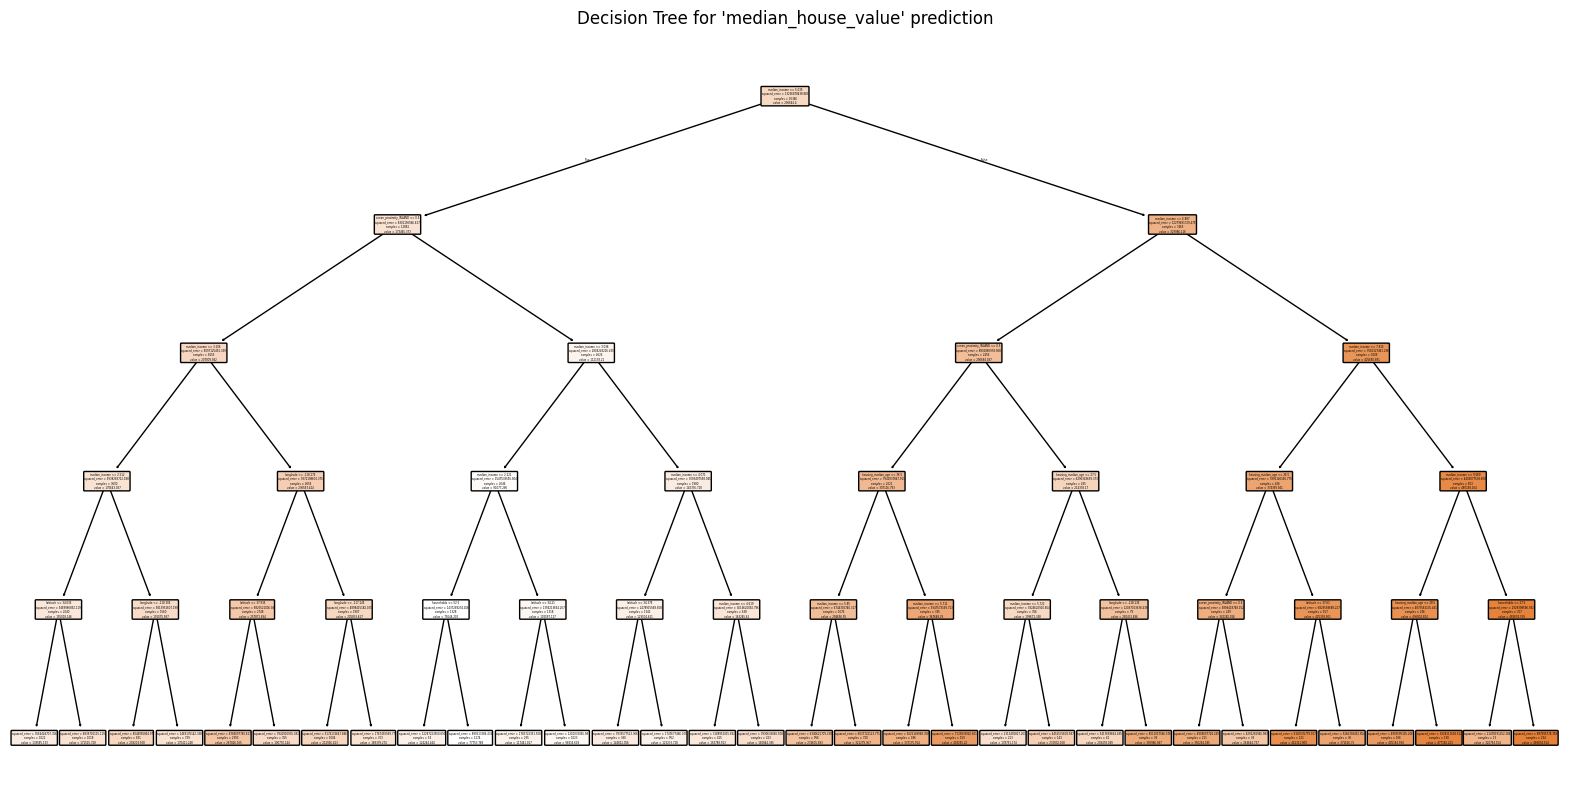

In [2]:
#Eliminar valores faltantes
df.dropna(subset=['total_bedrooms'], inplace=True)
df.reset_index(drop=True, inplace=True)

#Criar variável Dummy
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

#Definir variável target e variável preditora
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

#Separar dados pra treinamento e dados pra teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Criar e treinar uma Árvore de Regressão
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

#Plotar a Árvore de Regressão
plt.figure(figsize=(20,10))
tree.plot_tree(dt, filled=True, feature_names=X_train.columns.tolist(), rounded=True)
plt.title("Decision Tree for 'median_house_value' prediction")
plt.show()


### 2.  Calcule o caminho indicado pelos CCP-alfas dessa árvore.

In [3]:
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
display(pd.DataFrame({'ccp_alpha': ccp_alphas, 'impurity': impurities}).head())

,ccp_alpha,impurity
0,0.000000e+00,4.768927e+09
1,5.123259e+06,4.774051e+09
2,6.495780e+06,4.780546e+09
3,6.849918e+06,4.787396e+09
4,7.880858e+06,4.795277e+09


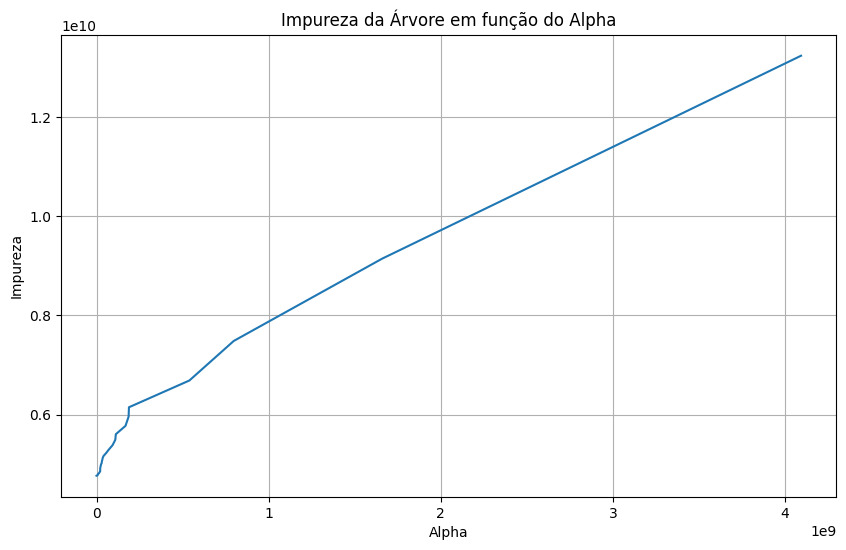

In [14]:
#A impureza da Árvore em função do Alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, impurities)
plt.xlabel("Alpha")
plt.ylabel("Impureza")
plt.title("Impureza da Árvore em função do Alpha")
plt.grid(True)


### 3. Paca cada valor de alpha obtido no item 2, treine uma árvore com o respectivo alfa, e guarde essa árvore em uma lista.

In [4]:
list_of_trees = []
for ccp_alpha in ccp_alphas:
    dt1 = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha)
    dt1.fit(X_train, y_train)
    list_of_trees.append(dt1)

In [ ]:
#Profundidade da Árvore em função do Alpha
tree_depths = [dt1.tree_.max_depth for dt1 in list_of_trees]
plt.figure(figsize=(10,6))
plt.plot(ccp_alphas[:-1], tree_depths[:-1])
plt.xlabel("Alpha")
plt.ylabel("Profundidade")
plt.title("Profundidade da Árvore em função do Alpha")
plt.grid(True)

### 4. Para cada árvore na lista, calcule o MSE da árvore.

In [ ]:
from sklearn.metrics import mean_squared_error

mse_values = []
for dt_model in list_of_trees:
    y_pred = dt_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)

display(pd.DataFrame({'ccp_alpha': ccp_alphas, 'mse': mse_values}).head())

### 5. Monte um gráfico do MSE pelo alpha, escolha um valor de alpha perto do ponto de mínimo do MSE

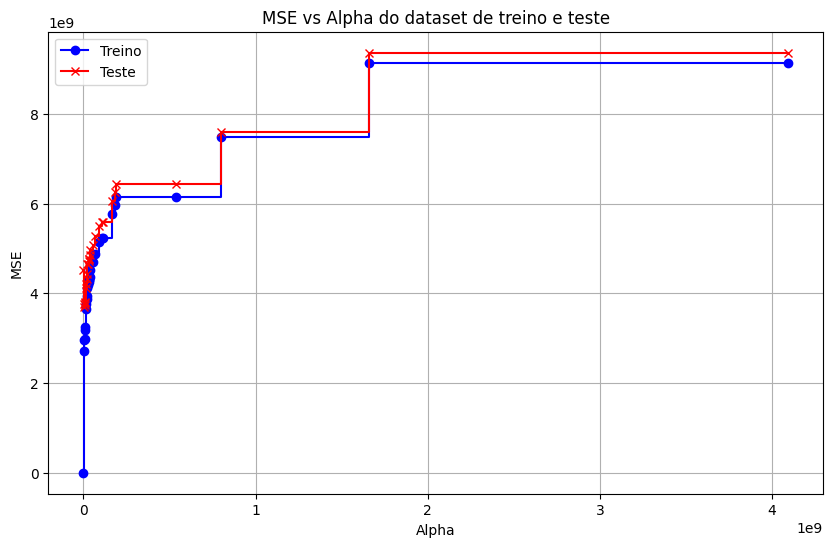

In [19]:
train_scores = [mean_squared_error(y_train, dt1.predict(X_train)) for dt1 in list_of_trees]
test_scores  = [mean_squared_error(y_test , dt1.predict(X_test )) for dt1 in list_of_trees]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("Alpha")
ax.set_ylabel("MSE")
ax.set_title("MSE vs Alpha do dataset de treino e teste")
ax.plot(ccp_alphas, train_scores, marker='o', label='Treino', drawstyle='steps-post', color='blue')
ax.plot(ccp_alphas, test_scores, marker='x', label='Teste', drawstyle='steps-post', color='red')
ax.legend()
ax.grid(True)
plt.show()

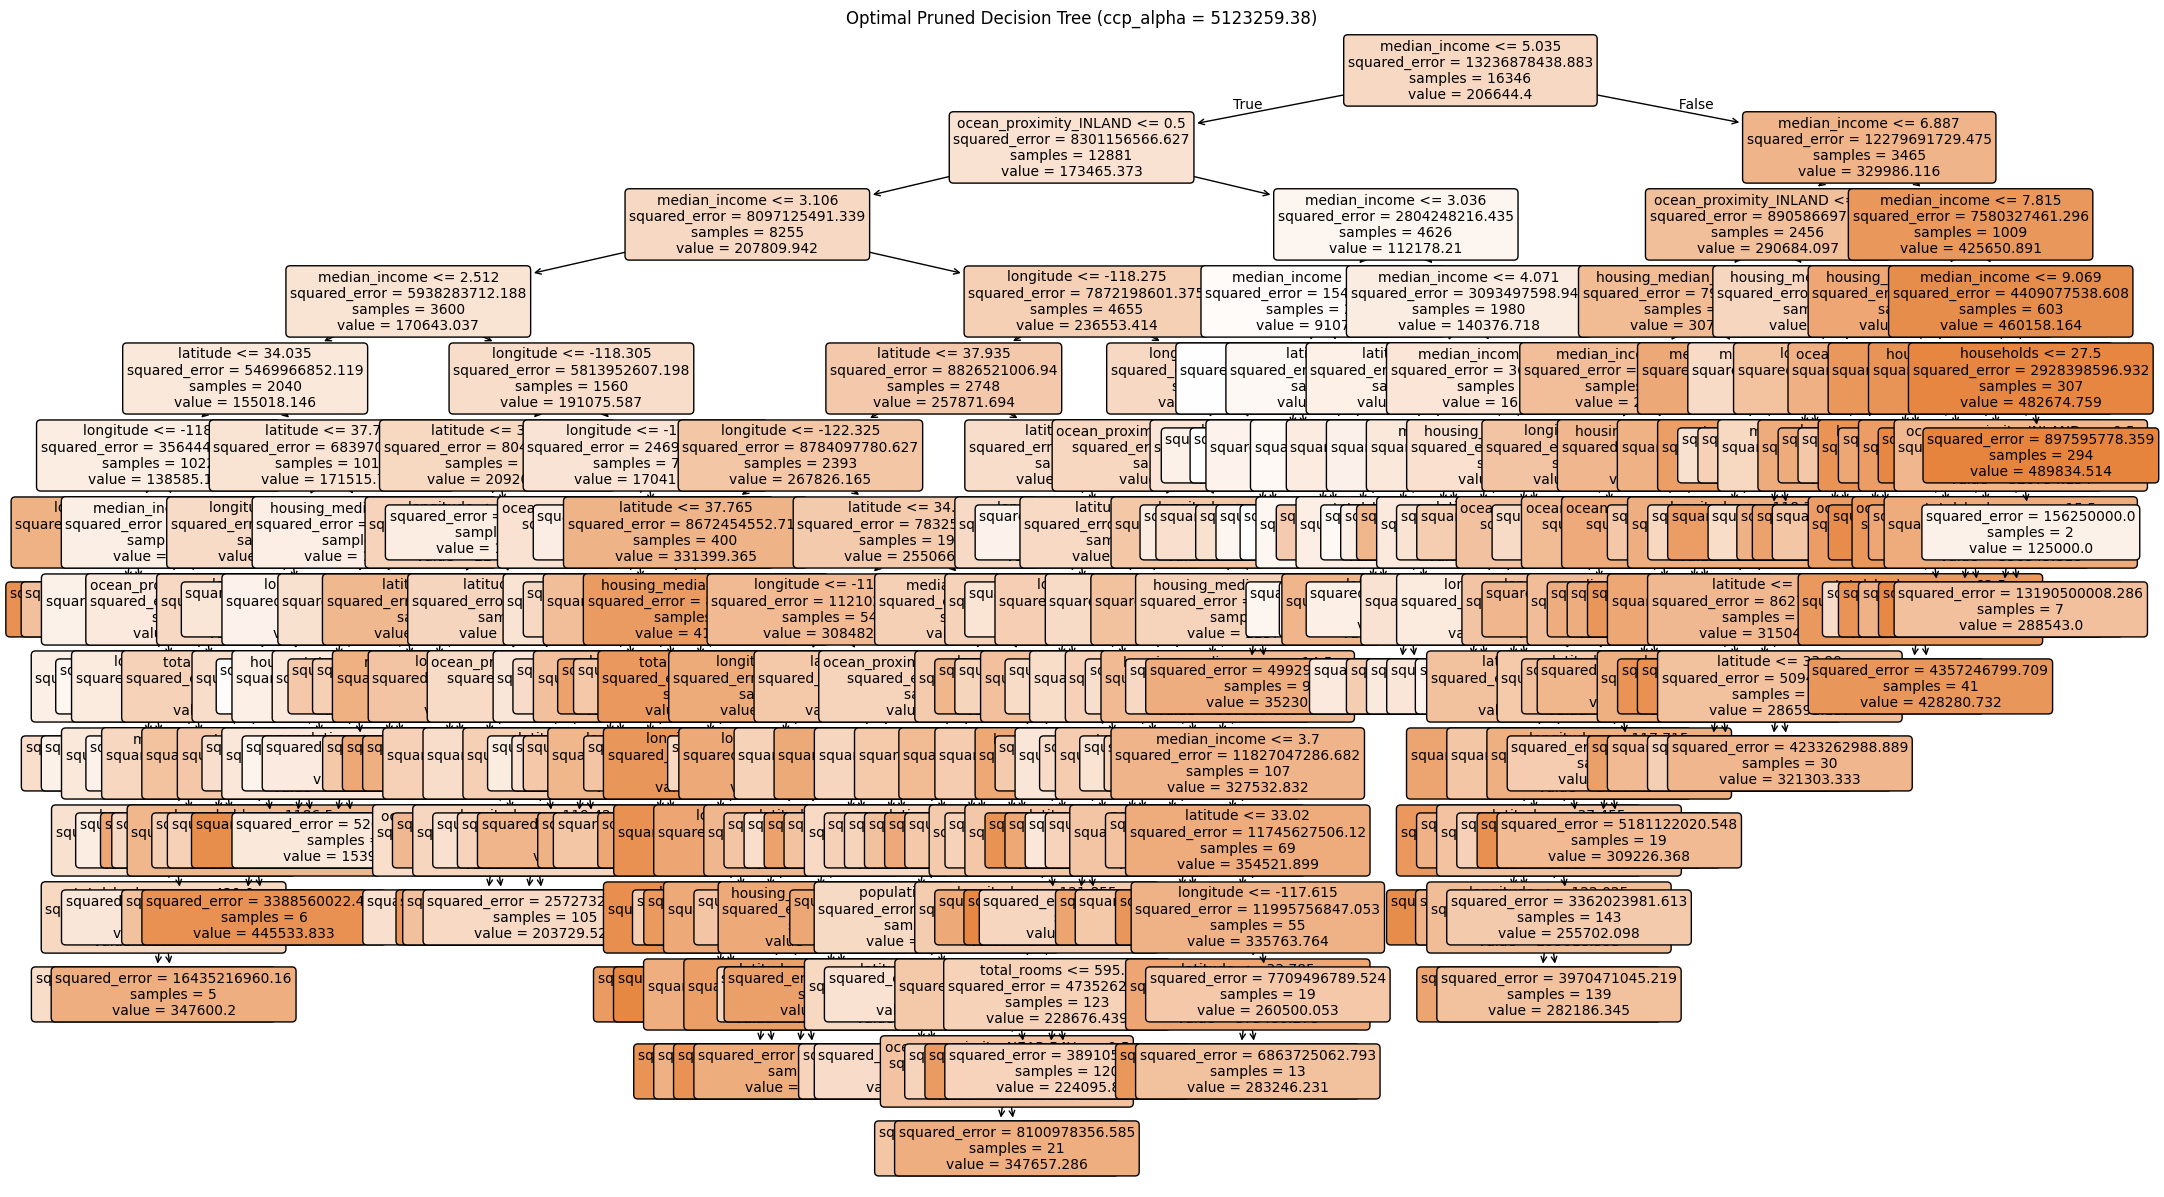

In [20]:
# Find the optimal tree from the list_of_trees
optimal_tree = None
for dt_model in list_of_trees:
    if dt_model.ccp_alpha == optimal_ccp_alpha:
        optimal_tree = dt_model
        break

if optimal_tree is not None:
    plt.figure(figsize=(25, 15))
    tree.plot_tree(optimal_tree, filled=True, feature_names=X_train.columns.tolist(), rounded=True, fontsize=10)
    plt.title(f"Optimal Pruned Decision Tree (ccp_alpha = {optimal_ccp_alpha:.2f})")
    plt.show()
else:
    print(f"Could not find a tree with ccp_alpha = {optimal_ccp_alpha}")

### 6. Calcule o R-quadrado dessa árvore encontrada no item acima

In [21]:
from sklearn.metrics import r2_score

if optimal_tree is not None:
    y_pred_optimal = optimal_tree.predict(X_test)
    r2 = r2_score(y_test, y_pred_optimal)
    print(f"R-squared score for the optimal tree on the test set: {r2:.4f}")
else:
    print("Optimal tree not found. Please ensure the previous step to identify the optimal tree was executed.")

R-squared score for the optimal tree on the test set: 0.7296


### 7. Visualize esta árvore.

In [22]:
if optimal_tree is not None:
    feature_importances = optimal_tree.feature_importances_
    feature_names = X_train.columns

    # Create a pandas Series for better visualization
    importances_df = pd.Series(feature_importances, index=feature_names)

    print("Feature Importances for the Optimal Tree:")
    display(importances_df.sort_values(ascending=False))
else:
    print("Optimal tree not found. Cannot retrieve feature importances.")

Feature Importances for the Optimal Tree:


,0
median_income,0.571387
ocean_proximity_INLAND,0.179035
latitude,0.095412
longitude,0.095050
housing_median_age,0.028399
ocean_proximity_NEAR OCEAN,0.010620
households,0.005433
population,0.005411
total_bedrooms,0.003810
total_rooms,0.003532
